In [1]:
# 1. Data Manipulation (The "Excel" of Python)
import pandas as pd 
import numpy as np

# 2. Visualization (The "Charts")
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Machine Learning (The "Brain")
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 4. Saving the Model (The "Memory")
import joblib

In [13]:
column_names = [
    'Year', 'DOY', 'Hour', 
    'Scalar_B', 'Bz', 'Proton_Density', 'Flow_Speed', 
    'Kp', 'F10_7'
]

# 2. Load the dataset
# We use 'delim_whitespace=True' because the file separates numbers with spaces
df = pd.read_csv(
    'solar_wind.csv', 
    delim_whitespace=True, 
    names=column_names, 
    header=None
)

C:\Users\Harshad koli\AppData\Local\Temp\ipykernel_21588\3648383130.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


In [ ]:
# Data Exploration

In [14]:
df.head(10)

,Year,DOY,Hour,Scalar_B,Bz,Proton_Density,Flow_Speed,Kp,F10_7
0,2015,1,0,6.1,1.1,2.8,568.0,23,132.9
1,2015,1,1,4.8,0.2,2.8,585.0,23,132.9
2,2015,1,2,4.3,-0.8,2.5,579.0,23,132.9
3,2015,1,3,4.0,0.4,2.7,560.0,10,132.9
4,2015,1,4,2.5,-0.1,2.8,554.0,10,132.9
5,2015,1,5,2.7,-0.0,2.7,566.0,10,132.9
6,2015,1,6,2.8,-0.2,2.9,560.0,10,132.9
7,2015,1,7,2.9,-0.6,2.9,556.0,10,132.9
8,2015,1,8,3.1,-1.3,2.6,531.0,10,132.9
9,2015,1,9,3.2,-0.5,2.7,518.0,10,132.9


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70152 entries, 0 to 70151
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Year            70152 non-null  int64  
 1   DOY             70152 non-null  int64  
 2   Hour            70152 non-null  int64  
 3   Scalar_B        70152 non-null  float64
 4   Bz              70152 non-null  float64
 5   Proton_Density  70152 non-null  float64
 6   Flow_Speed      70152 non-null  float64
 7   Kp              70152 non-null  int64  
 8   F10_7           70152 non-null  float64
dtypes: float64(5), int64(4)
memory usage: 4.8 MB


In [16]:
df.describe()


,Year,DOY,Hour,Scalar_B,Bz,Proton_Density,Flow_Speed,Kp,F10_7
count,70152.000000,70152.000000,70152.000000,70152.000000,70152.000000,70152.000000,70152.000000,70152.000000,70152.000000
mean,2018.501197,183.062949,11.500000,8.543641,3.446315,12.136094,456.433815,16.573084,88.588129
std,2.292274,105.475146,6.922236,56.169257,59.649611,74.689280,585.012603,12.554523,33.941778
min,2015.000000,1.000000,0.000000,0.500000,-26.200000,0.100000,259.000000,0.000000,63.400000
25%,2016.000000,92.000000,5.750000,3.700000,-1.500000,3.300000,349.000000,7.000000,70.300000
50%,2019.000000,183.000000,11.500000,4.800000,-0.100000,5.100000,401.000000,13.000000,76.600000
75%,2021.000000,274.000000,17.250000,6.300000,1.200000,8.100000,478.000000,23.000000,100.000000
max,2023.000000,366.000000,23.000000,999.900000,999.900000,999.900000,9999.000000,83.000000,999.900000


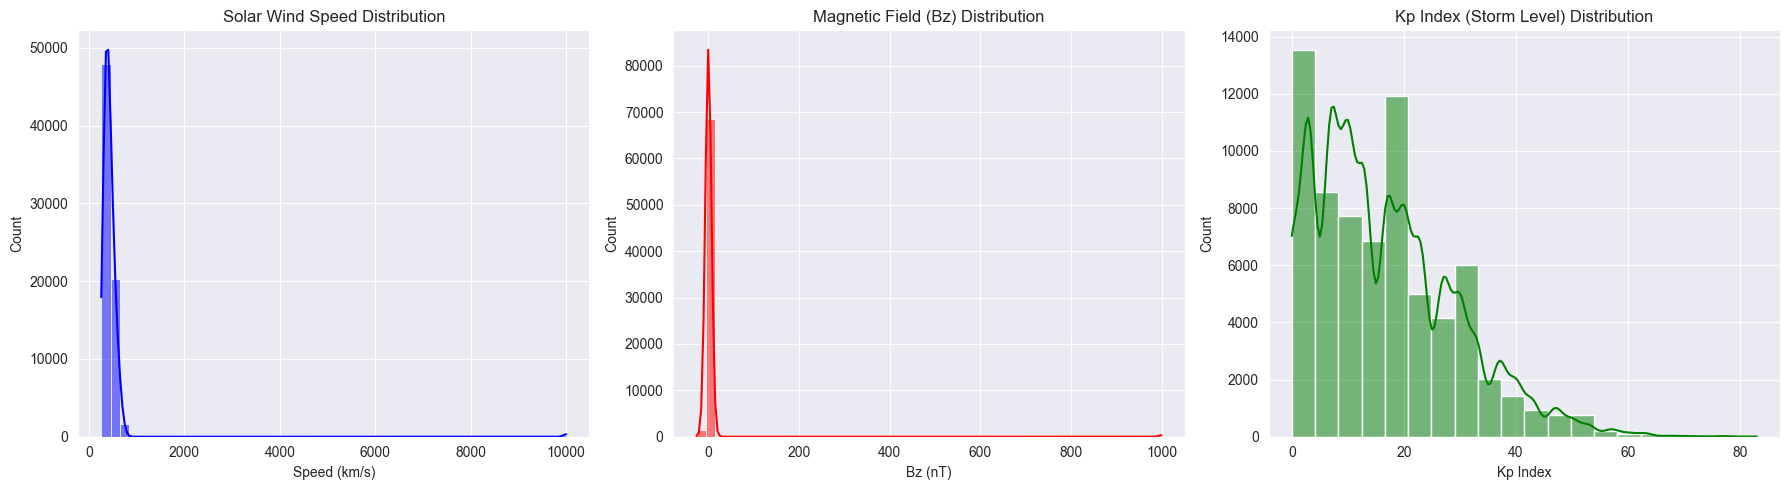

In [17]:
# looking for outliers 
# 1. Visualize the distribution of data
# We use histograms to see the "shape" of the wind speed, Bz, etc.

# Set the style for professional looking charts
sns.set_style("darkgrid")

# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Solar Wind Speed (Should be 300-800 km/s)
sns.histplot(df['Flow_Speed'], bins=50, kde=True, color='blue', ax=axes[0])
axes[0].set_title('Solar Wind Speed Distribution')
axes[0].set_xlabel('Speed (km/s)')

# Plot 2: Bz (Magnetic Field) (Should be -20 to +20 nT)
sns.histplot(df['Bz'], bins=50, kde=True, color='red', ax=axes[1])
axes[1].set_title('Magnetic Field (Bz) Distribution')
axes[1].set_xlabel('Bz (nT)')

# Plot 3: Kp Index (The Target) (Should be 0-9)
sns.histplot(df['Kp'], bins=20, kde=True, color='green', ax=axes[2])
axes[2].set_title('Kp Index (Storm Level) Distribution')
axes[2].set_xlabel('Kp Index')

plt.tight_layout()
plt.show()

In [18]:
# found outliers in Flow_Speed and Bz columns
# kp index suppose to be between 0-9

# 1. FIX THE KP SCALE
df['Kp'] = df['Kp'] / 10.0

# 2. REMOVE NASA ERROR CODES
# We replace specific error numbers with NaN (Not a Number)
# NASA often uses 999.9, 9999, or 99.9 as errors.
cols_to_clean = ['Scalar_B', 'Bz', 'Proton_Density', 'Flow_Speed']

for col in cols_to_clean:
    # Replace the specific error codes with NaN
    df[col] = df[col].replace([999.9, 9999, 99.9], np.nan)
    
    # Also, sometimes the error is just anything massive. 
    # Let's clip impossible values just to be safe:
    if col == 'Flow_Speed':
        df[col] = df[col].mask(df[col] > 2000) # Wind never exceeds 2000 km/s
    if col == 'Bz':
        df[col] = df[col].mask(df[col] > 100)  # Bz never exceeds 100 nT


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70152 entries, 0 to 70151
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Year            70152 non-null  int64  
 1   DOY             70152 non-null  int64  
 2   Hour            70152 non-null  int64  
 3   Scalar_B        69928 non-null  float64
 4   Bz              69902 non-null  float64
 5   Proton_Density  69755 non-null  float64
 6   Flow_Speed      69896 non-null  float64
 7   Kp              70152 non-null  float64
 8   F10_7           70152 non-null  float64
dtypes: float64(6), int64(3)
memory usage: 4.8 MB


In [20]:
# there were outliers in f10_7 column as well
# removing those outliers as well

df["F10_7"] = df["F10_7"].replace([999.9, 9999, 99.9, 999], np.nan)
df["F10_7"] = df["F10_7"].mask(df["F10_7"] > 500)

In [21]:
df.info()
# messed up the masking above, there are only 56k non null values now
# re-doing everything 
# details - gave "col" variable as input instead of F10_7, so it masked with respect to whatever column was in "col" variable

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70152 entries, 0 to 70151
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Year            70152 non-null  int64  
 1   DOY             70152 non-null  int64  
 2   Hour            70152 non-null  int64  
 3   Scalar_B        69928 non-null  float64
 4   Bz              69902 non-null  float64
 5   Proton_Density  69755 non-null  float64
 6   Flow_Speed      69896 non-null  float64
 7   Kp              70152 non-null  float64
 8   F10_7           70032 non-null  float64
dtypes: float64(6), int64(3)
memory usage: 4.8 MB


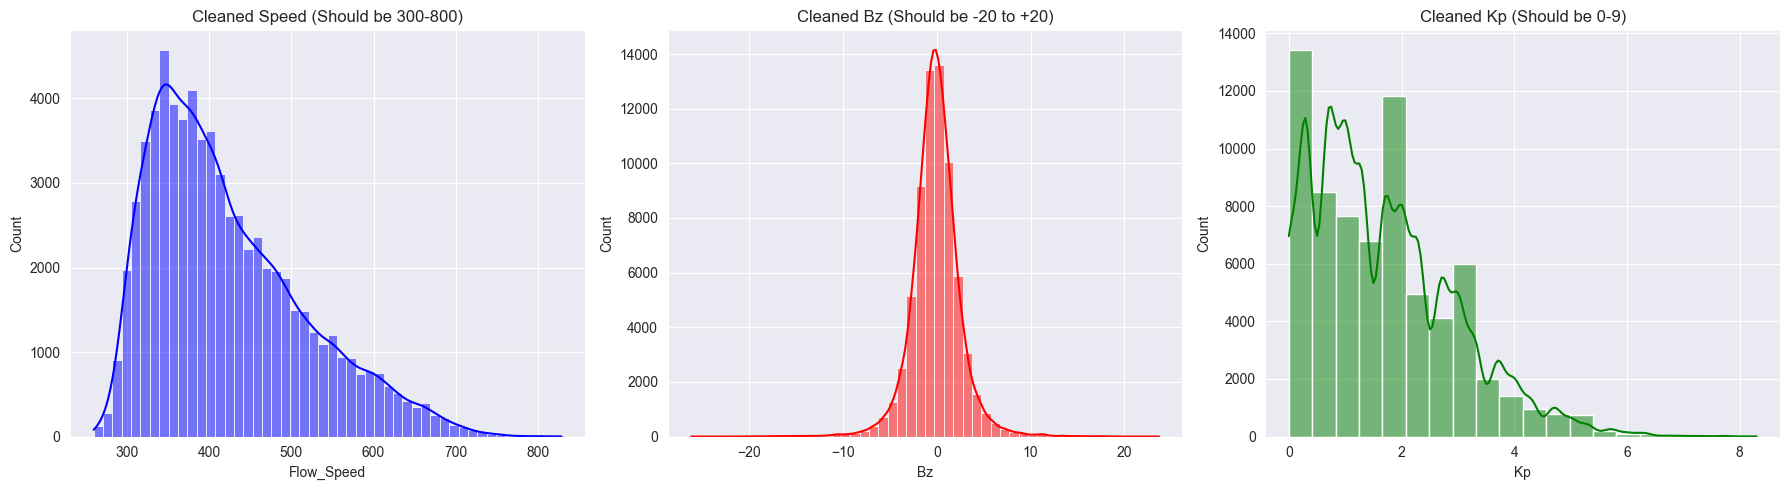

In [22]:
# dropping the Nan values and replotting the graphs

# 3. DROP THE BROKEN ROWS
df = df.dropna()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Speed (Should look like a nice hill around 400)
sns.histplot(df['Flow_Speed'], bins=50, kde=True, color='blue', ax=axes[0])
axes[0].set_title('Cleaned Speed (Should be 300-800)')

# Plot 2: Bz (Should be centered at 0)
sns.histplot(df['Bz'], bins=50, kde=True, color='red', ax=axes[1])
axes[1].set_title('Cleaned Bz (Should be -20 to +20)')

# Plot 3: Kp (Should be 0-9)
sns.histplot(df['Kp'], bins=20, kde=True, color='green', ax=axes[2])
axes[2].set_title('Cleaned Kp (Should be 0-9)')

plt.tight_layout()
plt.show()

In [23]:
# the plot shows data is variying correctly, and are in right ranges with no outliers

In [ ]:
# managing datetime index

df['Datetime'] = pd.to_datetime(
    df['Year'].astype(str) + '-' + df['DOY'].astype(str) + '-' + df['Hour'].astype(str), 
    format='%Y-%j-%H'
)

# SET IT AS THE INDEX
df = df.set_index('Datetime')

In [25]:
df.head()  # Display the first few rows of the dataframe

,Year,DOY,Hour,Scalar_B,Bz,Proton_Density,Flow_Speed,Kp,F10_7
Datetime,,,,,,,,,
2015-01-01 00:00:00,2015,1,0,6.1,1.1,2.8,568.0,2.3,132.9
2015-01-01 01:00:00,2015,1,1,4.8,0.2,2.8,585.0,2.3,132.9
2015-01-01 02:00:00,2015,1,2,4.3,-0.8,2.5,579.0,2.3,132.9
2015-01-01 03:00:00,2015,1,3,4.0,0.4,2.7,560.0,1.0,132.9
2015-01-01 04:00:00,2015,1,4,2.5,-0.1,2.8,554.0,1.0,132.9


In [26]:
df = df.drop(columns=['Year', 'DOY', 'Hour'])

In [27]:
df.head() 

,Scalar_B,Bz,Proton_Density,Flow_Speed,Kp,F10_7
Datetime,,,,,,
2015-01-01 00:00:00,6.1,1.1,2.8,568.0,2.3,132.9
2015-01-01 01:00:00,4.8,0.2,2.8,585.0,2.3,132.9
2015-01-01 02:00:00,4.3,-0.8,2.5,579.0,2.3,132.9
2015-01-01 03:00:00,4.0,0.4,2.7,560.0,1.0,132.9
2015-01-01 04:00:00,2.5,-0.1,2.8,554.0,1.0,132.9


In [28]:
# the data exploration and cleaning is done. 
# din't have much things to do as the columns were choosen specifially for this projects and din't require much cleaning.

In [29]:
# starting model training

In [30]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
''' decided to not randomly split the data as its time series data, 
    so training on past data and testing on future data is more logical'''

# 1. SORT BY TIME (Crucial for Time Series)
df = df.sort_index()

features = ['Scalar_B', 'Bz', 'Proton_Density', 'Flow_Speed', 'F10_7']
target = 'Kp'

X = df[features]
y = df[target]

# 2. DEFINE THE GRID (The settings we want to test)
# We test different number of trees (n_estimators) and depth (max_depth)
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

# 3. SETUP TIME-SERIES CROSS VALIDATION
# This ensures we don't cheat by looking at the future
# It trains on Jan, tests Feb. Then trains Jan+Feb, tests March...
tscv = TimeSeriesSplit(n_splits=3)

# 4. RUN THE GRID SEARCH (Hyperparameter Tuning)
rf = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=tscv,          # Use Time Series logic, not random shuffling
    scoring='r2',     # Optimize for Accuracy
    n_jobs=-1,        # Use all CPU cores
    verbose=1
)

# Train on the first 80% of data (Chronologically)
train_size = int(len(X) * 0.8)
X_train_time, X_test_time = X.iloc[:train_size], X.iloc[train_size:]
y_train_time, y_test_time = y.iloc[:train_size], y.iloc[train_size:]

grid_search.fit(X_train_time, y_train_time)

Fitting 3 folds for each of 18 candidates, totalling 54 fits


,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [10, 20, ...], 'min_samples_split': [2, 5], 'n_estimators': [50, 100, ...]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [31]:
best_model = grid_search.best_estimator_
print(f"\n Best Parameters Found: {grid_search.best_params_}")

# 6. FINAL TEST
# Test on the future data (The remaining 20% we held back)
final_predictions = best_model.predict(X_test_time)
final_r2 = r2_score(y_test_time, final_predictions)

print(f"(R²): {final_r2:.2f}")


 Best Parameters Found: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
(R²): 0.64


In [32]:
# R²: 0.64 is good but not good enough. 
# To improve the performance, doing feature engineering and adding more features.
# currently the prediction is done based on the current values of the features, 
# so adding lag features (wind speed an hour ago, average values etc) to help the model learn from past values as well.


# 1. CREATE LAGS (The "Rearview Mirror")
# Tell the model what happened 1 hour, 3 hours, and 6 hours ago
for col in ['Bz', 'Flow_Speed', 'Proton_Density', 'Kp']:
    df[f'{col}_lag1'] = df[col].shift(1)  # 1 hour ago
    df[f'{col}_lag3'] = df[col].shift(3)  # 3 hours ago
    df[f'{col}_lag6'] = df[col].shift(6)  # 6 hours ago

# 2. CREATE ROLLING MEANS (The "Trend")
# Is the wind speed trending up or down?
df['Speed_Mean_6h'] = df['Flow_Speed'].rolling(window=6).mean()
df['Bz_Mean_6h'] = df['Bz'].rolling(window=6).mean()

# 3. CREATE INTERACTION FEATURES (The "Physics Logic")
# Physics says: Pressure = Density * Speed^2
df['Dynamic_Pressure'] = df['Proton_Density'] * (df['Flow_Speed']**2)

# 4. CLEAN UP
# Shifting creates NaNs in the first 6 rows (because there is no "6 hours ago" for them).
df = df.dropna()

print("Features Engineered!")
print(f"New Feature Count: {len(df.columns)}")
print(df.head())

Features Engineered!
New Feature Count: 21
                     Scalar_B   Bz  Proton_Density  Flow_Speed   Kp  F10_7  \
Datetime                                                                     
2015-01-01 06:00:00       2.8 -0.2             2.9       560.0  1.0  132.9   
2015-01-01 07:00:00       2.9 -0.6             2.9       556.0  1.0  132.9   
2015-01-01 08:00:00       3.1 -1.3             2.6       531.0  1.0  132.9   
2015-01-01 09:00:00       3.2 -0.5             2.7       518.0  1.0  132.9   
2015-01-01 10:00:00       2.1  0.4             2.5       502.0  1.0  132.9   

                     Bz_lag1  Bz_lag3  Bz_lag6  Flow_Speed_lag1  ...  \
Datetime                                                         ...   
2015-01-01 06:00:00     -0.0      0.4      1.1            566.0  ...   
2015-01-01 07:00:00     -0.2     -0.1      0.2            560.0  ...   
2015-01-01 08:00:00     -0.6     -0.0     -0.8            556.0  ...   
2015-01-01 09:00:00     -1.3     -0.2      0.4    

In [ ]:
df.head(10) 

In [35]:
features = [
    'Scalar_B', 'Bz', 'Proton_Density', 'Flow_Speed', 'F10_7',
    'Bz_lag1', 'Bz_lag3', 'Bz_lag6',
    'Flow_Speed_lag1', 'Flow_Speed_lag3', 'Flow_Speed_lag6',
    'Kp_lag1', 'Kp_lag3', 'Kp_lag6',
    'Speed_Mean_6h', 'Bz_Mean_6h', 'Dynamic_Pressure'
]
target = 'Kp'

X = df[features]
y = df[target]

# 2. RE-RUN THE GRID SEARCH (Same code as before)
print("🧠 Retraining with Advanced Features...")

# (We reuse the previous setup)
train_size = int(len(X) * 0.8)
X_train_time, X_test_time = X.iloc[:train_size], X.iloc[train_size:]
y_train_time, y_test_time = y.iloc[:train_size], y.iloc[train_size:]

grid_search.fit(X_train_time, y_train_time)

🧠 Retraining with Advanced Features...
Fitting 3 folds for each of 18 candidates, totalling 54 fits


,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [10, 20, ...], 'min_samples_split': [2, 5], 'n_estimators': [50, 100, ...]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [36]:
best_model = grid_search.best_estimator_
final_predictions = best_model.predict(X_test_time)
final_r2 = r2_score(y_test_time, final_predictions)

print(f"R²: {final_r2:.2f}")

R²: 0.88


In [ ]:
# socre of 0.88 is too good. can go with this model for deployment
# new issue introduced - we would have to give the lag features i.e.,
# we need to give all the data (the 21  columns) for prediction in run time as well.
# this would have been problematic but since the dataset we will fetch from gives 24hr data, we can caluclate and provide all the lag features while in production

In [37]:
# saving the model for deployment

# 1. Save the GridSearch object (it contains the best model inside)
joblib.dump(best_model, 'solar_shield_model.pkl')

print("Brain Saved: 'solar_shield_model.pkl'")

Brain Saved: 'solar_shield_model.pkl'
